Dataset loaded successfully!
   case_id  Hospital_code Hospital_type_code  City_Code_Hospital  \
0        1              8                  c                   3   
1        2              2                  c                   5   
2        3             10                  e                   1   
3        4             26                  b                   2   
4        5             26                  b                   2   

  Hospital_region_code  Available Extra Rooms in Hospital    Department  \
0                    Z                                  3  radiotherapy   
1                    Z                                  2  radiotherapy   
2                    X                                  2    anesthesia   
3                    Y                                  2  radiotherapy   
4                    Y                                  2  radiotherapy   

  Ward_Type Ward_Facility_Code  Bed Grade  patientid  City_Code_Patient  \
0         R                  F      

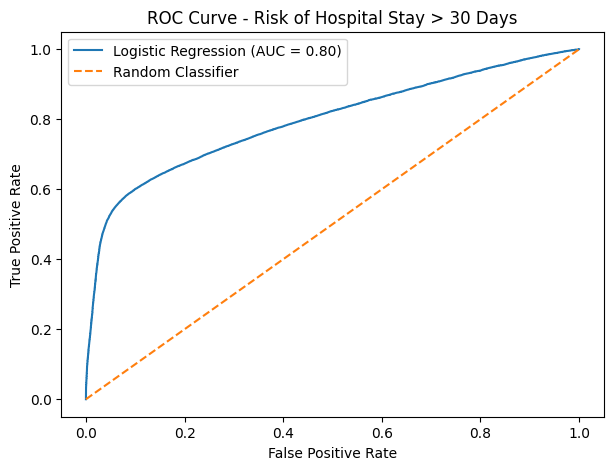

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# --------------------------------
# 1. Load Dataset
# --------------------------------
data = pd.read_csv("/content/Hospital_Data.csv.zip")

print("Dataset loaded successfully!")
print(data.head())

print("\nStay values:")
print(data["Stay"].value_counts())


# --------------------------------
# 2. Handle Missing Values
# --------------------------------

numeric_cols = data.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:
    data[col] = data[col].fillna(
        data[col].median()
    )


categorical_cols = data.select_dtypes(
    include=["object"]
).columns

for col in categorical_cols:
    data[col] = data[col].fillna(
        data[col].mode()[0]
    )


# --------------------------------
# 3. Create Binary Target
# --------------------------------

# 0 = Stay 30 days or less
# 1 = Stay more than 30 days

long_stay_categories = [
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "More than 100 Days"
]

data["long_stay"] = (
    data["Stay"]
    .isin(long_stay_categories)
    .astype(int)
)


print("\nTarget distribution:")
print(data["long_stay"].value_counts())


# --------------------------------
# 4. Features and Target
# --------------------------------

# Remove Stay because long_stay was created from it
# Remove IDs because they usually don't help prediction

X = data.drop(
    columns=[
        "Stay",
        "long_stay",
        "case_id",
        "patientid"
    ]
)

y = data["long_stay"]


# --------------------------------
# 5. Convert Categorical Variables
# --------------------------------

X = pd.get_dummies(
    X,
    drop_first=True
)


# --------------------------------
# 6. Train-Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# --------------------------------
# 7. Standardization
# --------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------
# 8. Logistic Regression
# L2 Regularization
# --------------------------------

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)

model.fit(X_train, y_train)


# --------------------------------
# 9. Predictions
# --------------------------------

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


# --------------------------------
# 10. Accuracy
# --------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(accuracy)


# --------------------------------
# 11. Confusion Matrix
# --------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------
# 12. Classification Report
# --------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# --------------------------------
# 13. ROC-AUC
# --------------------------------

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC Score:")
print(auc)


# --------------------------------
# 14. ROC Curve
# --------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Risk of Hospital Stay > 30 Days"
)

plt.legend()
plt.show()